In [1]:
"""
ApexPlanet Data Analytics Internship - Task 4
PART 3: Hypothesis Testing & Statistical Validation
Synthesises findings from Tasks 1-3 with formal statistical tests.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import sem, t as t_dist, chi2_contingency, ttest_ind
import os, warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style("whitegrid")
df = pd.read_csv('cleaned_dataset.csv')
OUT = './charts'
os.makedirs(OUT, exist_ok=True)

NAVY   = '#1E2761'
ICE    = '#CADCFC'
AMBER  = '#F4B942'
GREEN  = '#70AD47'
RED    = '#C0504D'
SLATE  = '#8A93A3'

In [3]:
def print_section(title):
    print('\n' + '='*65)
    print(f'  {title}')
    print('='*65)

def interpret_p(p, alpha=0.05):
    return (' REJECT H₀ — statistically significant'
            if p < alpha else
            'FAIL TO REJECT H₀ — not statistically significant')

# ── Helper: pre-compute repeat/one-time ──────────────────────
cust_orders = df.groupby('Customer_ID').size()
repeat_ids = cust_orders[cust_orders > 1].index
repeat_ltv = df[df['Customer_ID'].isin(repeat_ids)]\
               .groupby('Customer_ID')['Total_Sales'].sum()
onetime_ltv = df[~df['Customer_ID'].isin(repeat_ids)]\
                .groupby('Customer_ID')['Total_Sales'].sum()

In [4]:
# ─────────────────────────────────────────────────────────────
# DESCRIPTIVE STATS SUMMARY
# ─────────────────────────────────────────────────────────────
print_section("DESCRIPTIVE STATISTICS OVERVIEW")
num = df[['Age','Quantity','Unit_Price','Total_Sales']]
desc = num.describe().T
desc['skew'] = num.skew()
desc['cv_%'] = (num.std()/num.mean()*100).round(1)
print(desc.round(2))

# 95% CI for AOV
aov = df['Total_Sales'].mean()
se  = sem(df['Total_Sales'])
ci  = t_dist.interval(0.95, df=len(df)-1, loc=aov, scale=se)
print(f"\nAOV point estimate : ₹{aov:,.0f}")
print(f"95% Confidence Interval: (₹{ci[0]:,.0f}  –  ₹{ci[1]:,.0f})")


  DESCRIPTIVE STATISTICS OVERVIEW
              count       mean        std     min       25%        50%  \
Age          1000.0      41.35      13.68   18.00     30.00      41.00   
Quantity     1000.0       5.44       2.84    1.00      3.00       5.00   
Unit_Price   1000.0   25486.78   14179.40  145.78  13895.72   25398.74   
Total_Sales  1000.0  139399.44  114100.05  437.34  47066.63  108594.02   

                   75%        max  skew  cv_%  
Age              53.00      65.00  0.04  33.1  
Quantity          8.00      10.00  0.06  52.2  
Unit_Price    37512.38   49997.53 -0.03  55.6  
Total_Sales  203722.88  493677.50  0.99  81.9  

AOV point estimate : ₹139,399
95% Confidence Interval: (₹132,319  –  ₹146,480)


In [5]:
# ─────────────────────────────────────────────────────────────
# HYPOTHESIS 1 — Gender vs AOV (Independent t-test)
# ─────────────────────────────────────────────────────────────
print_section("H1: Do male and female customers spend equally? (t-test)")
H1_null = "H₀: Mean order value is equal for Male and Female customers"
H1_alt  = "H₁: Mean order value differs between Male and Female customers"
print(H1_null)
print(H1_alt)

male   = df[df['Gender']=='Male']['Total_Sales']
female = df[df['Gender']=='Female']['Total_Sales']
t1, p1 = ttest_ind(male, female, equal_var=False)

print(f"\nMale   mean : ₹{male.mean():,.0f}  (n={len(male)})")
print(f"Female mean : ₹{female.mean():,.0f}  (n={len(female)})")
print(f"t-statistic : {t1:.4f}")
print(f"p-value     : {p1:.4f}")
print(interpret_p(p1))
print("Business conclusion: Gender does NOT significantly predict spend → "
      "avoid gender-based pricing or targeting strategies.")



  H1: Do male and female customers spend equally? (t-test)
H₀: Mean order value is equal for Male and Female customers
H₁: Mean order value differs between Male and Female customers

Male   mean : ₹141,807  (n=511)
Female mean : ₹136,883  (n=489)
t-statistic : 0.6826
p-value     : 0.4950
FAIL TO REJECT H₀ — not statistically significant
Business conclusion: Gender does NOT significantly predict spend → avoid gender-based pricing or targeting strategies.


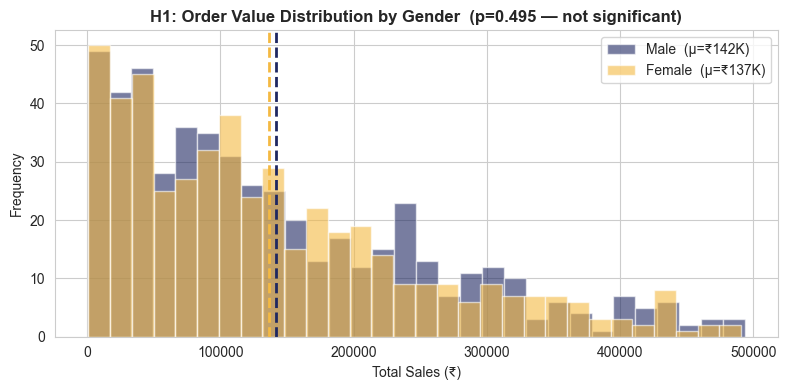

In [7]:
# CHART H1
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(male, bins=30, alpha=0.6, label=f'Male  (μ=₹{male.mean()/1000:.0f}K)', color=NAVY, edgecolor='white')
ax.hist(female, bins=30, alpha=0.6, label=f'Female  (μ=₹{female.mean()/1000:.0f}K)', color=AMBER, edgecolor='white')
ax.axvline(male.mean(),   color=NAVY,  linewidth=2, linestyle='--')
ax.axvline(female.mean(), color=AMBER, linewidth=2, linestyle='--')
ax.set_title(f'H1: Order Value Distribution by Gender  (p={p1:.3f} — not significant)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Total Sales (₹)'); ax.set_ylabel('Frequency')
ax.legend(); plt.tight_layout()
plt.show()
plt.savefig(f'{OUT}/h1_gender_aov.png', dpi=150); plt.close()


In [8]:
# ─────────────────────────────────────────────────────────────
# HYPOTHESIS 2 — Electronics AOV vs Other Categories (t-test)
# ─────────────────────────────────────────────────────────────
print_section("H2: Does Electronics have a higher AOV than other categories? (t-test)")
H2_null = "H₀: Mean order value for Electronics = Other categories"
H2_alt  = "H₁: Electronics has a higher mean order value"
print(H2_null); print(H2_alt)

elec     = df[df['Category']=='Electronics']['Total_Sales']
non_elec = df[df['Category']!='Electronics']['Total_Sales']
t2, p2   = ttest_ind(elec, non_elec, equal_var=False, alternative='greater')

print(f"\nElectronics mean : ₹{elec.mean():,.0f}  (n={len(elec)})")
print(f"Other cats mean  : ₹{non_elec.mean():,.0f}  (n={len(non_elec)})")
print(f"t-statistic : {t2:.4f}")
print(f"p-value     : {p2:.4f}")
print(interpret_p(p2))
print("Business conclusion: Electronics dominates revenue through ORDER VOLUME "
      "(354 orders, 36.4% revenue share), not a statistically higher per-order value.")



  H2: Does Electronics have a higher AOV than other categories? (t-test)
H₀: Mean order value for Electronics = Other categories
H₁: Electronics has a higher mean order value

Electronics mean : ₹143,442  (n=354)
Other cats mean  : ₹137,184  (n=646)
t-statistic : 0.8179
p-value     : 0.2068
FAIL TO REJECT H₀ — not statistically significant
Business conclusion: Electronics dominates revenue through ORDER VOLUME (354 orders, 36.4% revenue share), not a statistically higher per-order value.


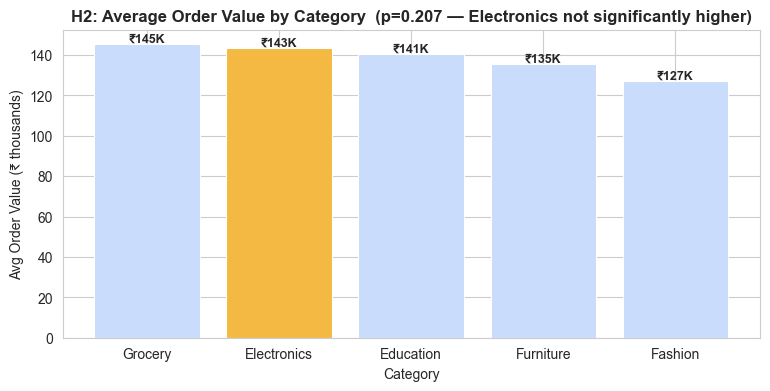

In [11]:
# CHART H2
fig, ax = plt.subplots(figsize=(9,4))
cat_means = df.groupby('Category')['Total_Sales'].mean().sort_values(ascending=False)
colors = [AMBER if c=='Electronics' else ICE for c in cat_means.index]
bars = ax.bar(cat_means.index, cat_means.values/1000, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title(f'H2: Average Order Value by Category  (p={p2:.3f} — Electronics not significantly higher)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Avg Order Value (₹ thousands)')
ax.set_xlabel('Category')
for bar, val in zip(bars, cat_means.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'₹{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')
plt.show()
plt.tight_layout(); plt.savefig(f'{OUT}/h2_electronics_aov.png', dpi=150); plt.close()


In [12]:
# ─────────────────────────────────────────────────────────────
# HYPOTHESIS 3 — Revenue tier distribution vs Gender (Chi-squared)
# ─────────────────────────────────────────────────────────────
print_section("H3: Is revenue tier distribution independent of gender? (Chi-squared)")
H3_null = "H₀: Revenue tier (Low/Medium/High) is independent of Gender"
H3_alt  = "H₁: Revenue tier distribution differs by Gender"
print(H3_null); print(H3_alt)

ct = pd.crosstab(df['Gender'], df['Revenue_Category'])
chi2_val, p3, dof, expected = chi2_contingency(ct)

print(f"\nObserved counts:\n{ct}")
print(f"\nchi2-statistic : {chi2_val:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value        : {p3:.4f}")
print(interpret_p(p3))
print("Business conclusion: Purchase tier is equally distributed across genders → "
      "revenue tiers are NOT a useful gender-segmentation criterion.")


  H3: Is revenue tier distribution independent of gender? (Chi-squared)
H₀: Revenue tier (Low/Medium/High) is independent of Gender
H₁: Revenue tier distribution differs by Gender

Observed counts:
Revenue_Category  High_Revenue  Low_Revenue  Medium_Revenue
Gender                                                     
Female                     165          162             162
Male                       175          168             168

chi2-statistic : 0.0283
Degrees of freedom: 2
p-value        : 0.9859
FAIL TO REJECT H₀ — not statistically significant
Business conclusion: Purchase tier is equally distributed across genders → revenue tiers are NOT a useful gender-segmentation criterion.


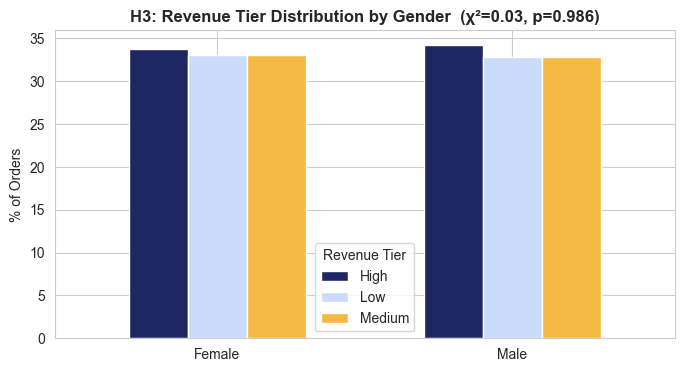

In [13]:
 #CHART H3
fig, ax = plt.subplots(figsize=(8,4))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=ax, color=[NAVY, ICE, AMBER], edgecolor='white', width=0.6)
ax.set_title(f'H3: Revenue Tier Distribution by Gender  (χ²={chi2_val:.2f}, p={p3:.3f})',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% of Orders'); ax.set_xlabel('')
ax.set_xticklabels(ct_pct.index, rotation=0)
ax.legend(title='Revenue Tier', labels=['High','Low','Medium'])
plt.show()
plt.tight_layout(); plt.savefig(f'{OUT}/h3_gender_tier_chi2.png', dpi=150); plt.close()

In [14]:
# ─────────────────────────────────────────────────────────────
# HYPOTHESIS 4 — Repeat vs One-Time LTV (t-test) ← KEY FINDING
# ─────────────────────────────────────────────────────────────
print_section("H4: Do repeat customers have higher lifetime value? (t-test)  ← KEY")
H4_null = "H₀: Mean lifetime value of repeat customers = one-time customers"
H4_alt  = "H₁: Repeat customers have higher lifetime value (one-tailed)"
print(H4_null); print(H4_alt)

t4, p4 = ttest_ind(repeat_ltv, onetime_ltv, equal_var=False, alternative='greater')

print(f"\nRepeat   mean LTV : ₹{repeat_ltv.mean():,.0f}  (n={len(repeat_ltv)})")
print(f"One-time mean LTV : ₹{onetime_ltv.mean():,.0f}  (n={len(onetime_ltv)})")
print(f"LTV ratio          : {repeat_ltv.mean()/onetime_ltv.mean():.2f}×")
print(f"t-statistic : {t4:.4f}")
print(f"p-value     : {p4:.8f}")
print(interpret_p(p4))
print("Business conclusion: STRONG statistical evidence that repeat customers are worth "
      f"₹{(repeat_ltv.mean()-onetime_ltv.mean())/1000:.0f}K more per customer. "
      "Every 1% shift from one-time to repeat = meaningful revenue gain.")



  H4: Do repeat customers have higher lifetime value? (t-test)  ← KEY
H₀: Mean lifetime value of repeat customers = one-time customers
H₁: Repeat customers have higher lifetime value (one-tailed)

Repeat   mean LTV : ₹311,035  (n=52)
One-time mean LTV : ₹137,682  (n=895)
LTV ratio          : 2.26×
t-statistic : 6.6216
p-value     : 0.00000001
 REJECT H₀ — statistically significant
Business conclusion: STRONG statistical evidence that repeat customers are worth ₹173K more per customer. Every 1% shift from one-time to repeat = meaningful revenue gain.


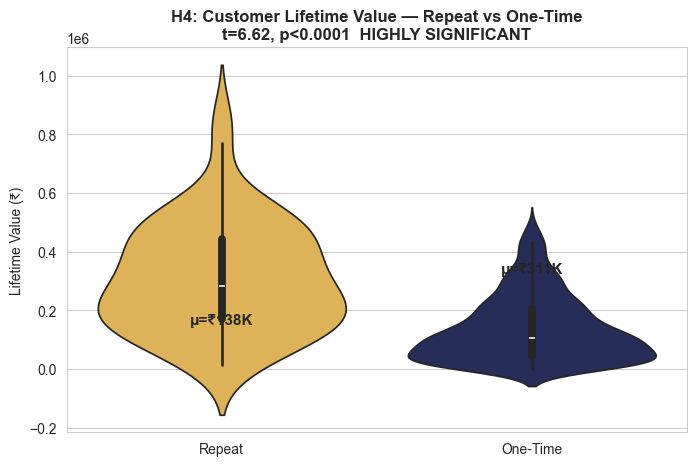

In [15]:
# CHART H4 — violin + box
fig, ax = plt.subplots(figsize=(8,5))
plot_data = pd.DataFrame({
    'LTV': list(repeat_ltv) + list(onetime_ltv),
    'Type': ['Repeat']*len(repeat_ltv) + ['One-Time']*len(onetime_ltv)
})
sns.violinplot(data=plot_data, x='Type', y='LTV', hue='Type',
               palette={'Repeat': AMBER, 'One-Time': NAVY},
               inner='box', ax=ax, legend=False)
ax.set_title(f'H4: Customer Lifetime Value — Repeat vs One-Time\n'
             f't={t4:.2f}, p<0.0001  HIGHLY SIGNIFICANT',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Lifetime Value (₹)'); ax.set_xlabel('')
for i, (label, grp) in enumerate(plot_data.groupby('Type')):
    ax.text(i, grp['LTV'].mean() + 15000,
            f'μ=₹{grp["LTV"].mean()/1000:.0f}K', ha='center',
            fontweight='bold', fontsize=11)
plt.show()
plt.tight_layout(); plt.savefig(f'{OUT}/h4_repeat_vs_onetime_ltv.png', dpi=150); plt.close()


In [16]:
# ─────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────
print_section("HYPOTHESIS TESTING SUMMARY")
summary = [
    ['H1','t-test','Gender vs AOV',           f'{p1:.4f}',' Not significant','Gender irrelevant for pricing'],
    ['H2','t-test','Electronics AOV vs Others',f'{p2:.4f}',' Not significant','Volume, not price, drives dominance'],
    ['H3','χ²-test','Revenue tier vs Gender',  f'{p3:.4f}',' Not significant','Tiers distributed equally by gender'],
    ['H4','t-test','Repeat vs One-Time LTV',   f'{p4:.2e}',' SIGNIFICANT p<0.0001','Retain customers → 2.26× LTV'],
]
print(f"\n{'ID':<4} {'Test':<10} {'Hypothesis':<30} {'p-value':<12} {'Result':<24} {'Business Action'}")
print('-'*110)
for row in summary:
    print(f"{row[0]:<4} {row[1]:<10} {row[2]:<30} {row[3]:<12} {row[4]:<24} {row[5]}")

print('\n4 hypothesis charts saved to', OUT)


  HYPOTHESIS TESTING SUMMARY

ID   Test       Hypothesis                     p-value      Result                   Business Action
--------------------------------------------------------------------------------------------------------------
H1   t-test     Gender vs AOV                  0.4950        Not significant         Gender irrelevant for pricing
H2   t-test     Electronics AOV vs Others      0.2068        Not significant         Volume, not price, drives dominance
H3   χ²-test    Revenue tier vs Gender         0.9859        Not significant         Tiers distributed equally by gender
H4   t-test     Repeat vs One-Time LTV         9.02e-09      SIGNIFICANT p<0.0001    Retain customers → 2.26× LTV

4 hypothesis charts saved to ./charts
